In [19]:
import numpy as np
import math
import matplotlib.pyplot as plt


## Week 1: Linear regression without built in libraries

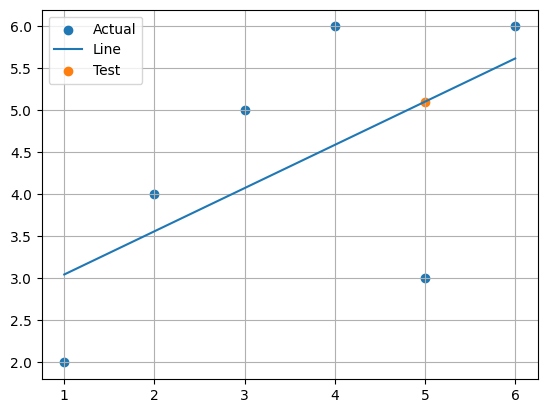

In [20]:
x = [1,2,3,4,5,6]
y = [2,4,5,6,3,6]
n = len(x)
sx = sum(x)
sy = sum(y)
xy = sum(x[i]*y[i] for i in range(n))
x2 = sum(x[i]**2 for i in range(n))
m = (n*xy - (sx*sy))/(n*x2 - sx**2)
c = (sy - m*sx)/n
# print(m, n)

def predic(o):
  return m*o + c

y_pred = [predic(o) for o in x]
mse = sum((y[i]-y_pred[i])**2 for i in range(n)) / n
rmse = math.sqrt(mse)

plt.figure()
plt.scatter(x,y, label = 'Actual')
plt.plot(x,y_pred, label = 'Line')
x_test = 5
y_test = predic(x_test)
plt.scatter(x_test, y_test, label = 'Test')
plt.legend()
plt.grid()
plt.show()

## Week 2: Linear regression with built in libraries

m 0.39999999999999997 c 4.0


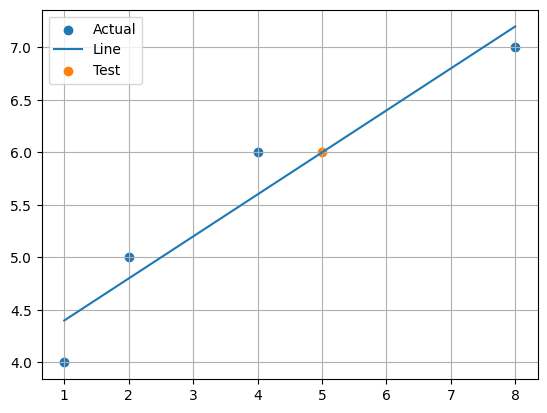

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

x = np.array([1,2,4,8]).reshape(-1,1)
y = np.array([4,5,6,7])

model = LinearRegression()
model.fit(x,y)

m = model.coef_[0]
c = model.intercept_
print("m",m, "c", c)

y_pred = model.predict(x)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)

x_test = np.array([5])
y_test = model.predict(x_test.reshape(-1,1))

plt.figure()
plt.scatter(x,y, label = 'Actual')
plt.plot(x,y_pred, label = 'Line')
plt.scatter(x_test, y_test, label = 'Test')
plt.legend()
plt.grid()
plt.show()


## Week 3: Naive Bayes implementation ( No plot )

In [22]:
data = pd.read_csv('/content/sample_data/Iris1.csv')
data.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [23]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

data = pd.read_csv('/content/sample_data/Iris1.csv')

x = data[['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']]
y = data['Species']

le = LabelEncoder()
y = le.fit_transform(y)

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.3, random_state= 5)

model = GaussianNB()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print(accuracy_score(y_test, y_pred))

0.9333333333333333


## Week 4: ID3 with plot


93.33333333333333


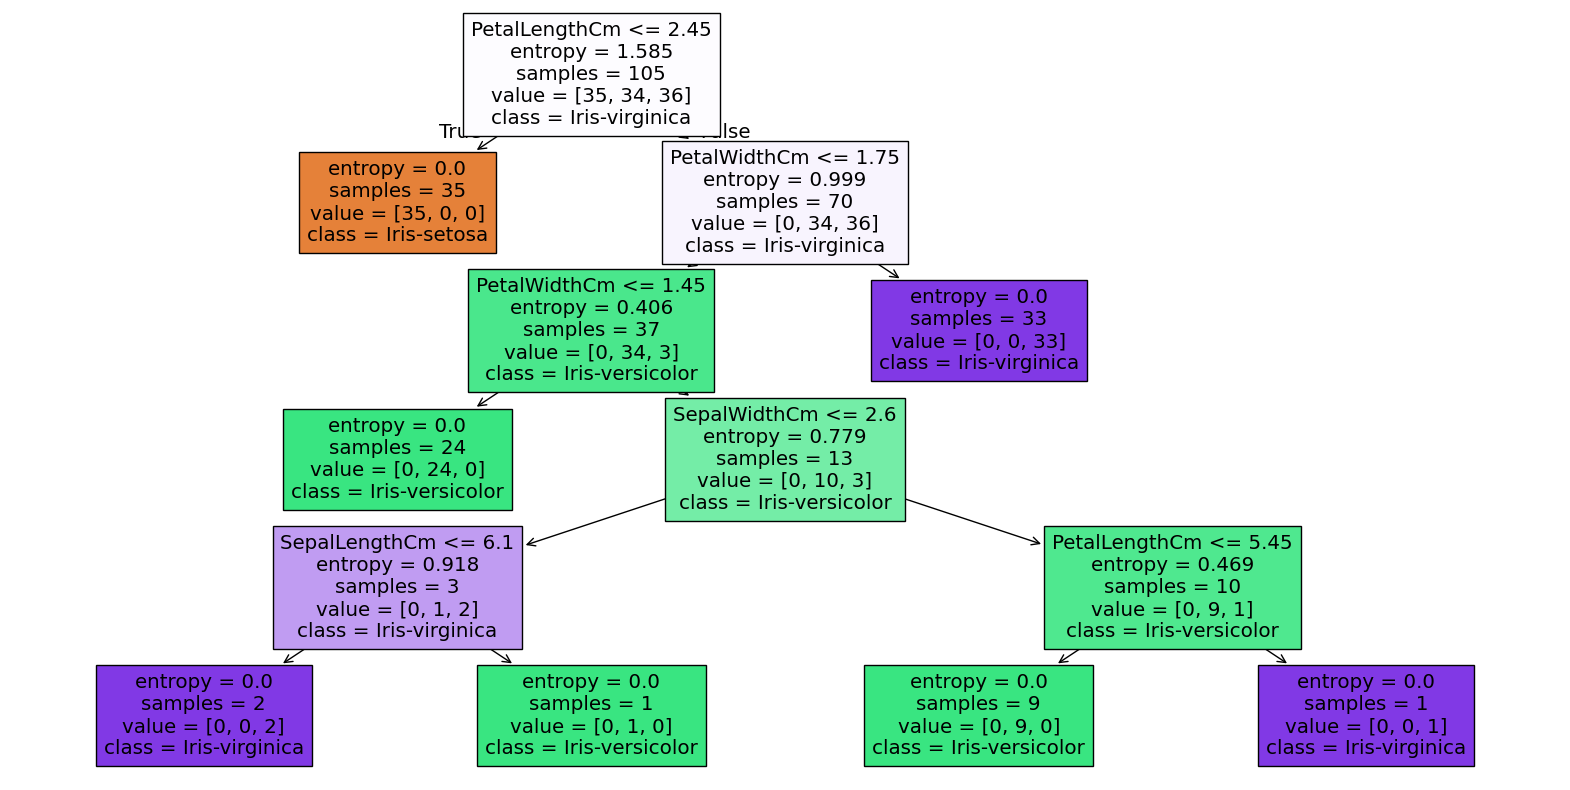

In [24]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

data = pd.read_csv('/content/sample_data/Iris1.csv')

x = data[['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']]
y = data['Species']

le = LabelEncoder()
y = le.fit_transform(y)

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.3, random_state= 5)

model = DecisionTreeClassifier(criterion='entropy')
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print(accuracy_score(y_test, y_pred) * 100)

plt.figure(figsize=(20,10))
plot_tree(model,
          filled=True,
          feature_names=x.columns,
          class_names=le.classes_)
plt.show()

## Week 5: CART with plot

91.11111111111111


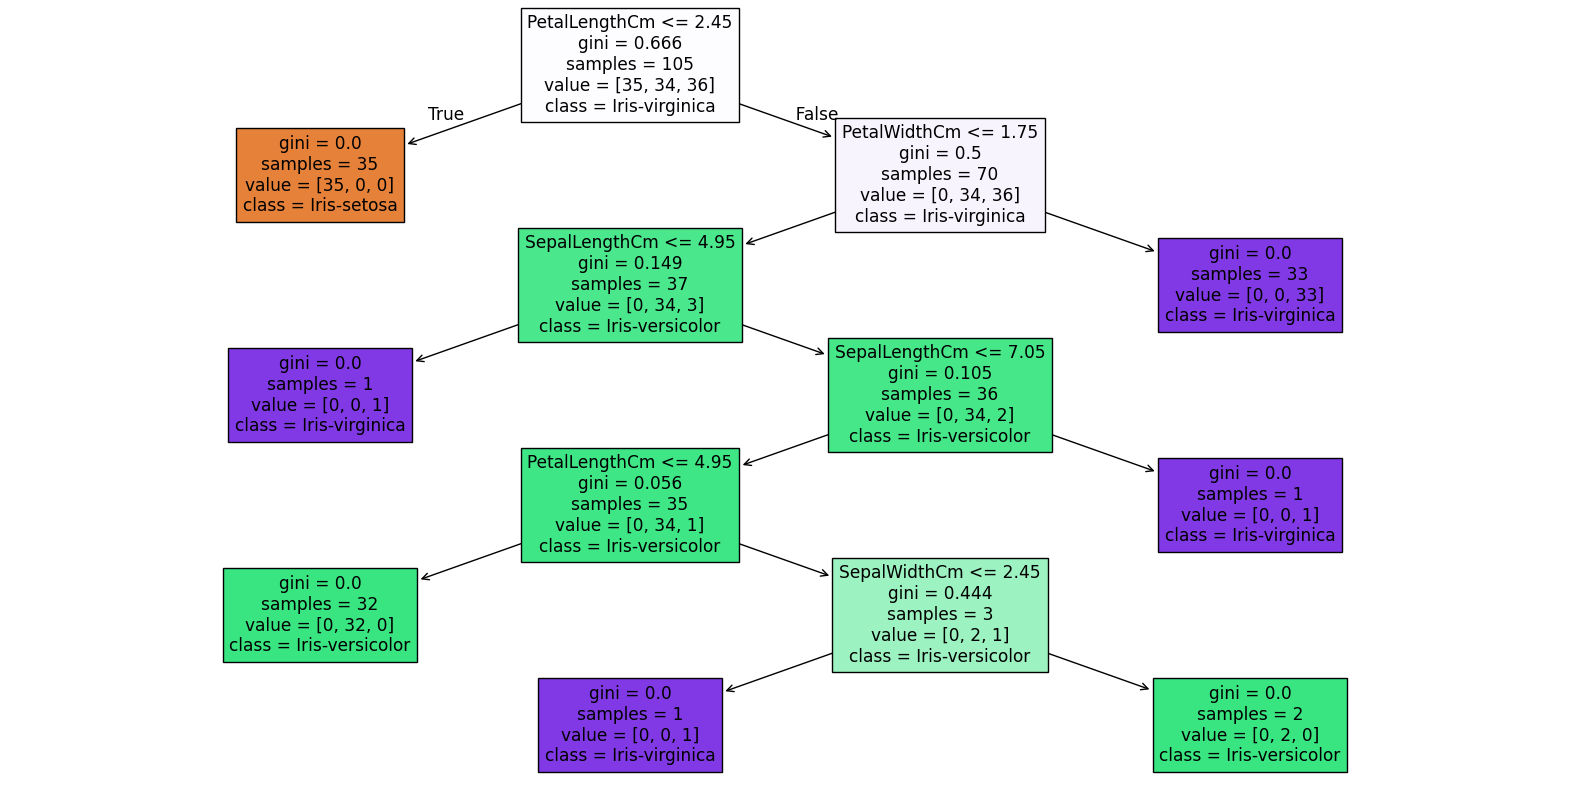

In [25]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

data = pd.read_csv('/content/sample_data/Iris1.csv')

x = data[['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']]
y = data['Species']

le = LabelEncoder()
y = le.fit_transform(y)

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.3, random_state= 5)

model = DecisionTreeClassifier(criterion='gini')
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print(accuracy_score(y_test, y_pred) * 100)

plt.figure(figsize=(20,10))
plot_tree(model,
          filled=True,
          feature_names=x.columns,
          class_names=le.classes_)
plt.show()

## Week 6: K Neighbors Classifier

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

data = pd.read_csv('/content/sample_data/Iris1.csv')

x = data.iloc[:,:-1]
y = data.iloc[:,-1]


x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.3, random_state= 5)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

best_k = 1
best_acc = 0
for k in range(1,11):
  model = KNeighborsClassifier(n_neighbors=k)
  model.fit(x_train, y_train)

  acc = accuracy_score(y_test, model.predict(x_test))
  if acc > best_acc:
    best_acc = acc
    best_k = k
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(x_train, y_train)

print(best_k, accuracy_score(y_test, final_model.predict(x_test)))

1 1.0


## Week 7: SVM

0.9298245614035088
0.9239766081871345


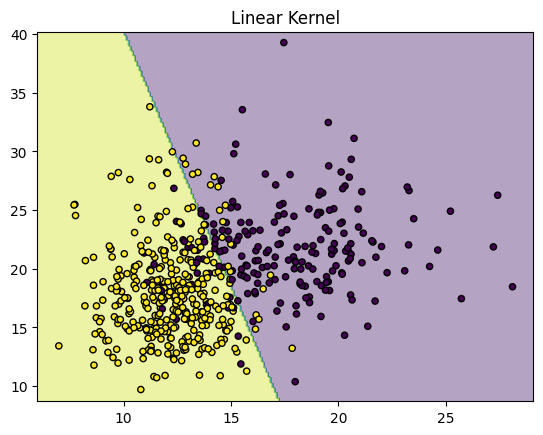

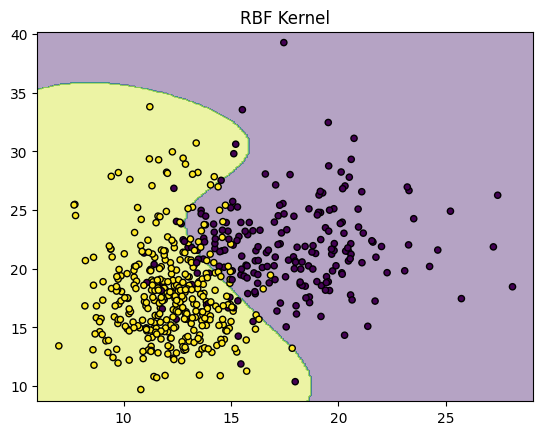

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

data = datasets.load_breast_cancer()

x = data.data[:,:2]
y = data.target

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.3, random_state= 5)

linear_model = SVC(kernel='linear')
linear_model.fit(x_train, y_train)
y_pred_linear = linear_model.predict(x_test)

rbf_model = SVC(kernel='rbf')
rbf_model.fit(x_train, y_train)
y_pred_rbf = rbf_model.predict(x_test)

print(accuracy_score(y_test, y_pred_linear))
print(accuracy_score(y_test, y_pred_rbf))
def plot_bon(model, x,y,title):
  x_min, x_max = x[:, 0].min() - 1, x[:, 0].max() + 1
  y_min, y_max = x[:, 1].min() - 1, x[:, 1].max() + 1

  xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                       np.arange(y_min, y_max, 0.1))
  z = model.predict(np.c_[xx.ravel(), yy.ravel()])
  z = z.reshape(xx.shape)
  plt.figure()
  plt.contourf(xx, yy, z, alpha=0.4)
  plt.scatter(x[:, 0], x[:, 1], c=y, s=20, edgecolor='k')
  plt.title(title)
  plt.show()

plot_bon(linear_model, x,y, 'Linear Kernel')
plot_bon(rbf_model, x,y, 'RBF Kernel')

## Week 8: K Means

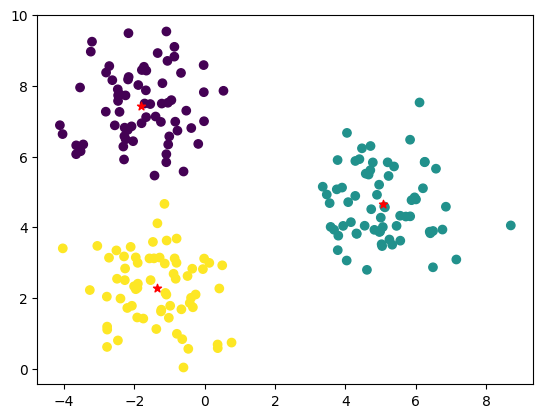

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

x,y = make_blobs(n_samples=200, centers=3)

kmeans=KMeans(n_clusters=3)
kmeans.fit(x)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_

plt.figure()
plt.scatter(x[:,0], x[:,1], c=labels)
plt.scatter(centroids[:,0], centroids[:,1], marker='*', c='red')
plt.show()

## Week 9: EM vs KMeans

K-Means Silhouette Score: 0.452949780355554
EM Silhouette Score: 0.44249183226269917


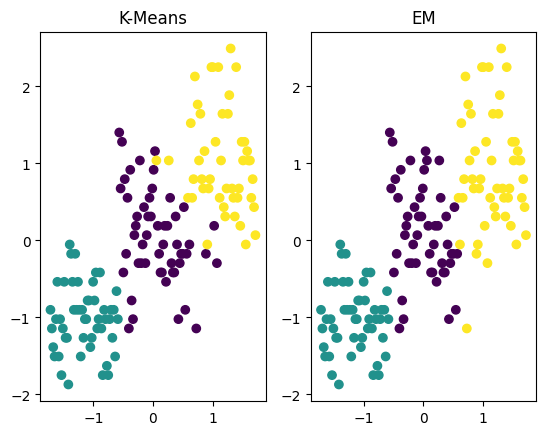

In [30]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score


df = pd.read_csv('/content/sample_data/Iris1.csv')

x = df.select_dtypes(include=[np.number])

true_labels = None
if 'species' in df.columns:
    true_labels = df['species'].astype('category').cat.codes

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

kmeans = KMeans(n_clusters=3, random_state=0)
kmeans_labels = kmeans.fit_predict(x_scaled)
em = GaussianMixture(n_components=3, random_state=0)
em_labels = em.fit_predict(x_scaled)

print("K-Means Silhouette Score:", silhouette_score(x_scaled, kmeans_labels))
print("EM Silhouette Score:", silhouette_score(x_scaled, em_labels))

plt.figure()
plt.subplot(1,2,1)
plt.scatter(x_scaled[:,0], x_scaled[:,1], c=kmeans_labels)
plt.title('K-Means')
plt.subplot(1,2,2)
plt.scatter(x_scaled[:,0], x_scaled[:,1], c=em_labels)
plt.title('EM')
plt.show()

## Week 10: Single Layer perceptron

In [34]:
import pandas as pd
import numpy as np

from sklearn.linear_model import Perceptron
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

data = load_iris()
x = data.data[:,:2]
y = data.target

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.3, random_state= 5)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

model = Perceptron(max_iter=100, eta0=0.1)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print(accuracy_score(y_test, y_pred))
print('Weights', model.coef_)
print('Bias', model.intercept_)

0.7333333333333333
Weights [[-0.35518269  0.2027945 ]
 [-0.01085563 -0.10264394]
 [ 0.27953251  0.01412912]]
Bias [-0.2 -0.2 -0.1]
